In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.ticker as mtick
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PALETTE = ['#6366f1','#f59e0b','#10b981','#ef4444','#3b82f6','#ec4899']
sns.set_palette(PALETTE)

In [10]:
path = Path('/content/drive/MyDrive/Datathon_VinTelligence/data/data_clean')
df = pd.read_csv(path / 'Dataset_4_Marketing_Traffic.csv')
df['date'] = pd.to_datetime(df['date'])
df['year']      = df['date'].dt.year
df['month']     = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek
df['day_name']  = df['date'].dt.day_name()
df['return_ratio'] = df['sessions'] / df['unique_visitors']
print(f"Shape: {df.shape}")
df.head()

Shape: (3652, 16)


,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source,orders_n,revenue_net,conversion_rate,AOV,year,month,dayofweek,day_name,return_ratio
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search,80.0,1501578.07,0.008197,18769.725875,2013,1,1,Tuesday,1.345650
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search,18.0,766660.48,0.001721,42592.248889,2013,1,2,Wednesday,1.282787
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct,4.0,167151.91,0.000397,41787.977500,2013,1,3,Thursday,1.351032
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct,5.0,130838.23,0.000501,26167.646000,2013,1,4,Friday,1.236885
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral,8.0,258038.00,0.000783,32254.750000,2013,1,5,Saturday,1.297006


In [11]:
df.info()
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      3652 non-null   datetime64[ns]
 1   sessions                  3652 non-null   int64         
 2   unique_visitors           3652 non-null   int64         
 3   page_views                3652 non-null   int64         
 4   bounce_rate               3652 non-null   float64       
 5   avg_session_duration_sec  3652 non-null   float64       
 6   traffic_source            3652 non-null   object        
 7   orders_n                  3652 non-null   float64       
 8   revenue_net               3652 non-null   float64       
 9   conversion_rate           3652 non-null   float64       
 10  AOV                       3652 non-null   float64       
 11  year                      3652 non-null   int32         
 12  month               

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,orders_n,revenue_net,conversion_rate,AOV,year,month,dayofweek,return_ratio
count,3652,3652.00,3652.00,3652.00,3652.00,3652.00,3652.00,3652.00,3652.00,3652.00,3652.00,3652.00,3652.0,3652.00
mean,2017-12-31 12:00:00,25041.77,19031.40,108615.22,0.00,210.28,33.29,807129.49,0.00,25574.66,2017.50,6.52,3.0,1.32
min,2013-01-01 00:00:00,7973.00,6136.00,30451.00,0.00,100.10,0.00,0.00,0.00,0.00,2013.00,1.00,0.0,1.22
25%,2015-07-02 18:00:00,17099.25,12915.00,72982.00,0.00,156.70,15.00,368505.82,0.00,19716.60,2015.00,4.00,1.0,1.27
50%,2017-12-31 12:00:00,23633.50,17924.00,101010.50,0.00,209.20,26.00,638295.02,0.00,25163.83,2017.50,7.00,3.0,1.32
75%,2020-07-01 06:00:00,31782.75,24191.75,138086.00,0.01,266.20,43.00,1056879.44,0.00,30396.48,2020.00,10.00,5.0,1.37
max,2022-12-31 00:00:00,50947.00,40430.00,275560.00,0.01,319.90,215.00,5602292.80,0.01,98462.56,2022.00,12.00,6.0,1.43
std,NaN,9422.61,7237.95,44472.06,0.00,63.77,27.07,637391.00,0.00,8529.27,2.87,3.45,2.0,0.06


# 1. Phân tích Chất lượng Traffic (Acquisition Quality)
> Traffic từ nguồn nào mang lại đúng đối tượng mục tiêu?

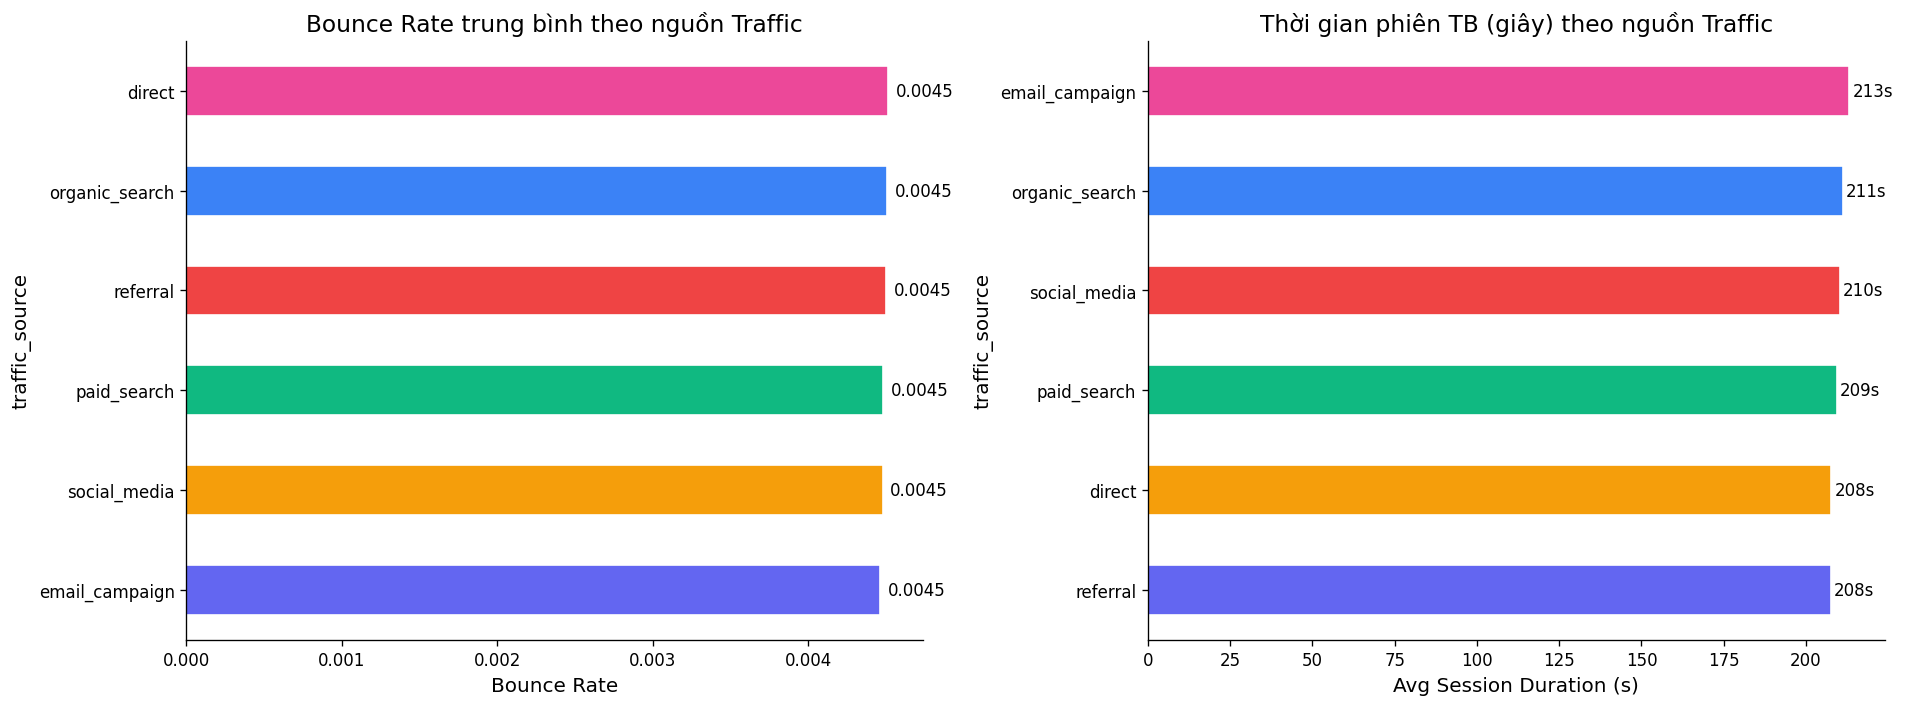

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bounce Rate
src_bounce = df.groupby('traffic_source')['bounce_rate'].mean().sort_values()
src_bounce.plot.barh(ax=axes[0], color=PALETTE[:len(src_bounce)], edgecolor='white')
axes[0].set_title('Bounce Rate trung bình theo nguồn Traffic')
axes[0].set_xlabel('Bounce Rate')
for i, v in enumerate(src_bounce):
    axes[0].text(v + 0.00005, i, f'{v:.4f}', va='center', fontsize=10)

# Avg Session Duration
src_dur = df.groupby('traffic_source')['avg_session_duration_sec'].mean().sort_values()
src_dur.plot.barh(ax=axes[1], color=PALETTE[:len(src_dur)], edgecolor='white')
axes[1].set_title('Thời gian phiên TB (giây) theo nguồn Traffic')
axes[1].set_xlabel('Avg Session Duration (s)')
for i, v in enumerate(src_dur):
    axes[1].text(v + 1, i, f'{v:.0f}s', va='center', fontsize=10)

plt.tight_layout()
plt.show()

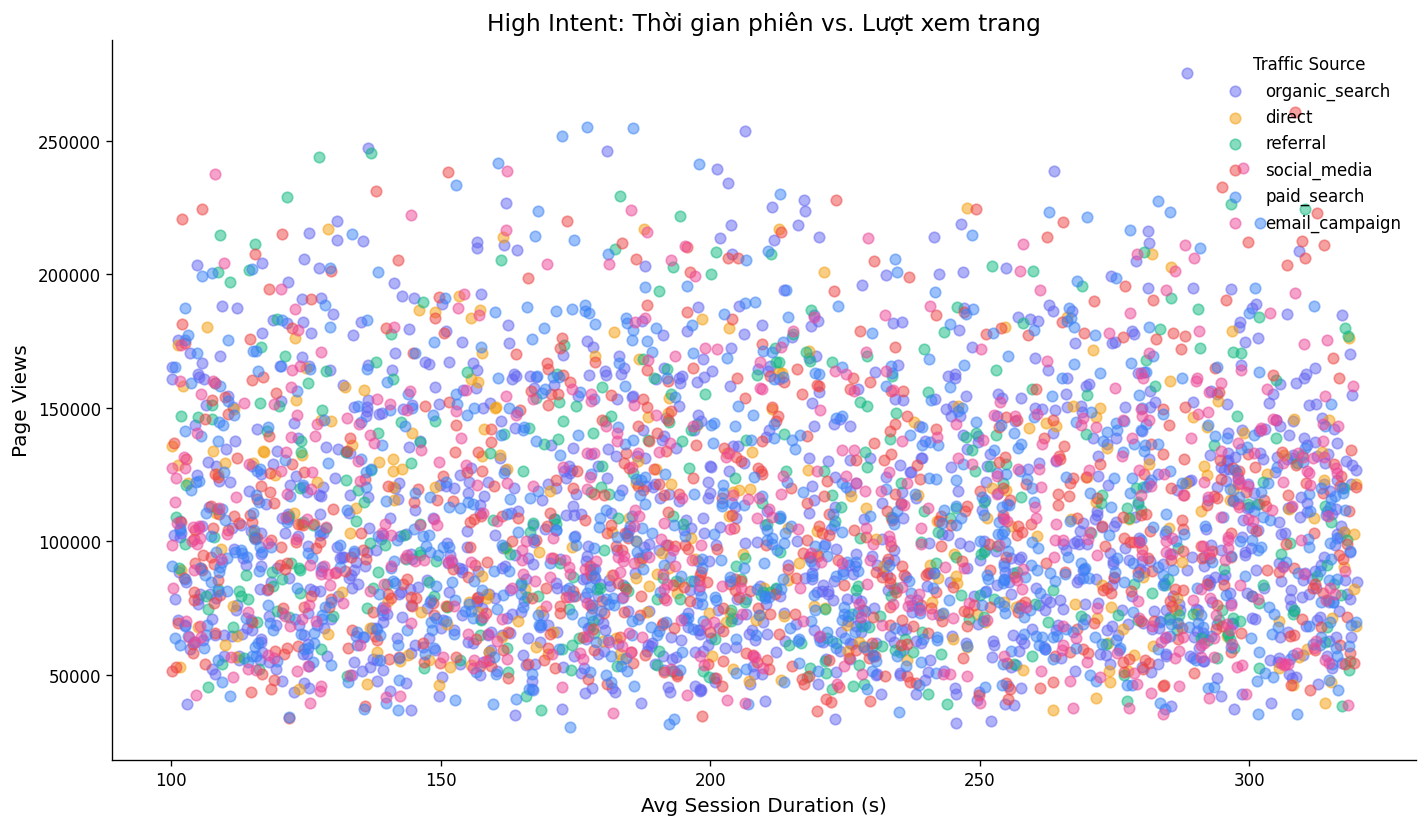

In [13]:
fig, ax = plt.subplots(figsize=(12, 7))
for i, src in enumerate(df['traffic_source'].unique()):
    sub = df[df['traffic_source'] == src]
    ax.scatter(sub['avg_session_duration_sec'], sub['page_views'],
               alpha=0.5, label=src, s=40, color=PALETTE[i % len(PALETTE)])
ax.set_xlabel('Avg Session Duration (s)')
ax.set_ylabel('Page Views')
ax.set_title('High Intent: Thời gian phiên vs. Lượt xem trang')
ax.legend(title='Traffic Source', frameon=False)
plt.tight_layout()
plt.show()

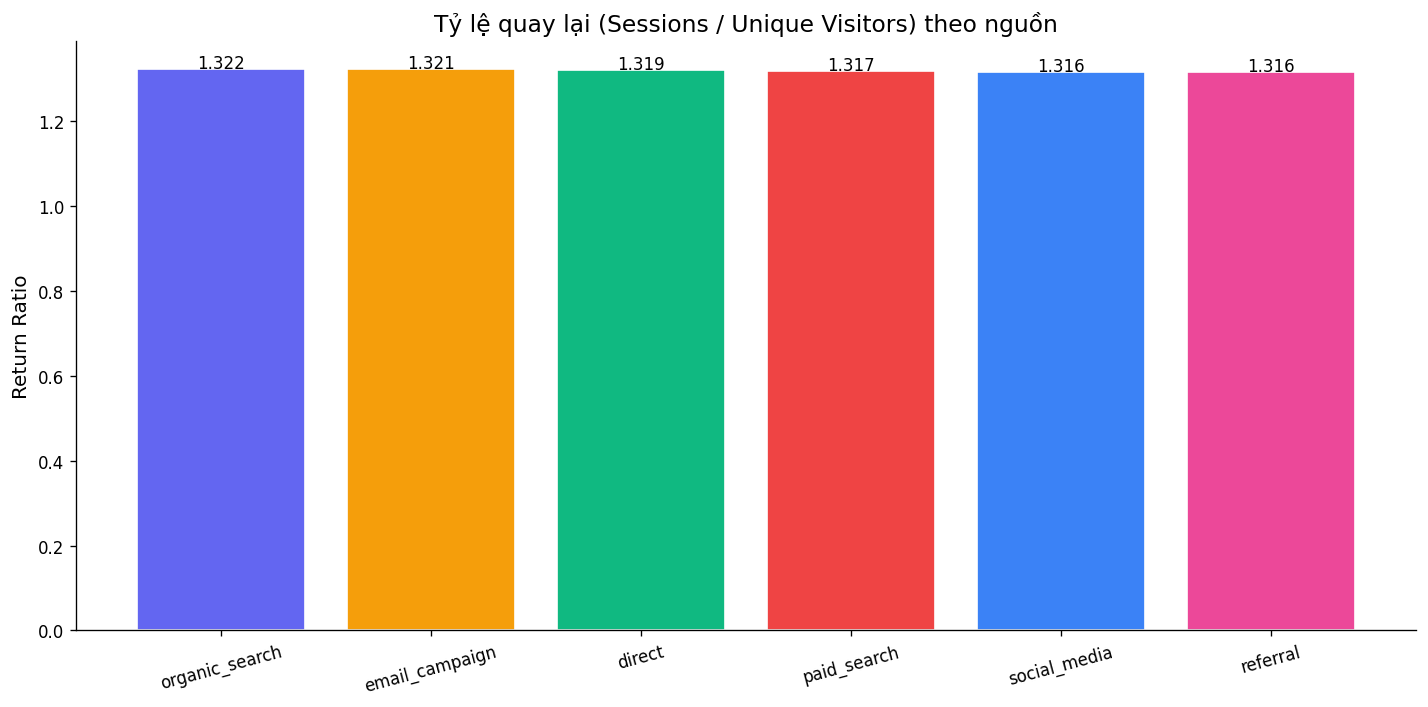

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
src_return = df.groupby('traffic_source')['return_ratio'].mean().sort_values(ascending=False)
bars = ax.bar(src_return.index, src_return.values, color=PALETTE[:len(src_return)], edgecolor='white')
ax.set_title('Tỷ lệ quay lại (Sessions / Unique Visitors) theo nguồn')
ax.set_ylabel('Return Ratio')
for bar, v in zip(bars, src_return.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.3f}', ha='center', fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

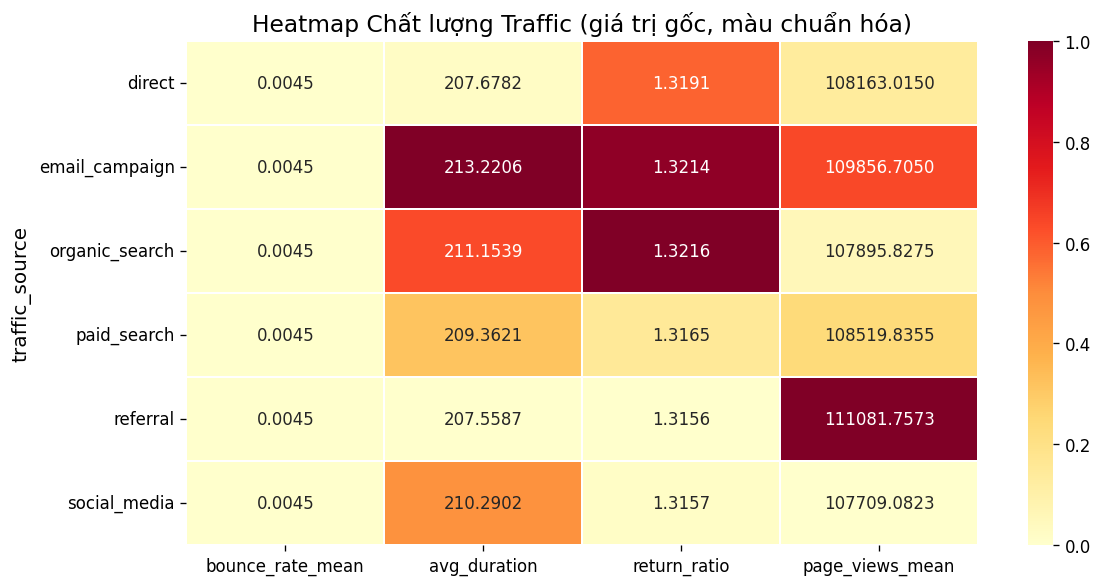

In [15]:
quality_metrics = df.groupby('traffic_source').agg(
    bounce_rate_mean=('bounce_rate','mean'),
    avg_duration=('avg_session_duration_sec','mean'),
    return_ratio=('return_ratio','mean'),
    page_views_mean=('page_views','mean')
).round(4)

# Normalize for heatmap
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
quality_norm = pd.DataFrame(
    scaler.fit_transform(quality_metrics),
    index=quality_metrics.index,
    columns=quality_metrics.columns
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(quality_norm, annot=quality_metrics.values, fmt='.4f',
            cmap='YlOrRd', linewidths=1, ax=ax)
ax.set_title('Heatmap Chất lượng Traffic (giá trị gốc, màu chuẩn hóa)')
plt.tight_layout()
plt.show()

# 2. Phân tích Hiệu quả Chuyển đổi (Conversion Performance)
> Nguồn nào đang chuyển đổi tốt nhất? Đáng để rót ngân sách?

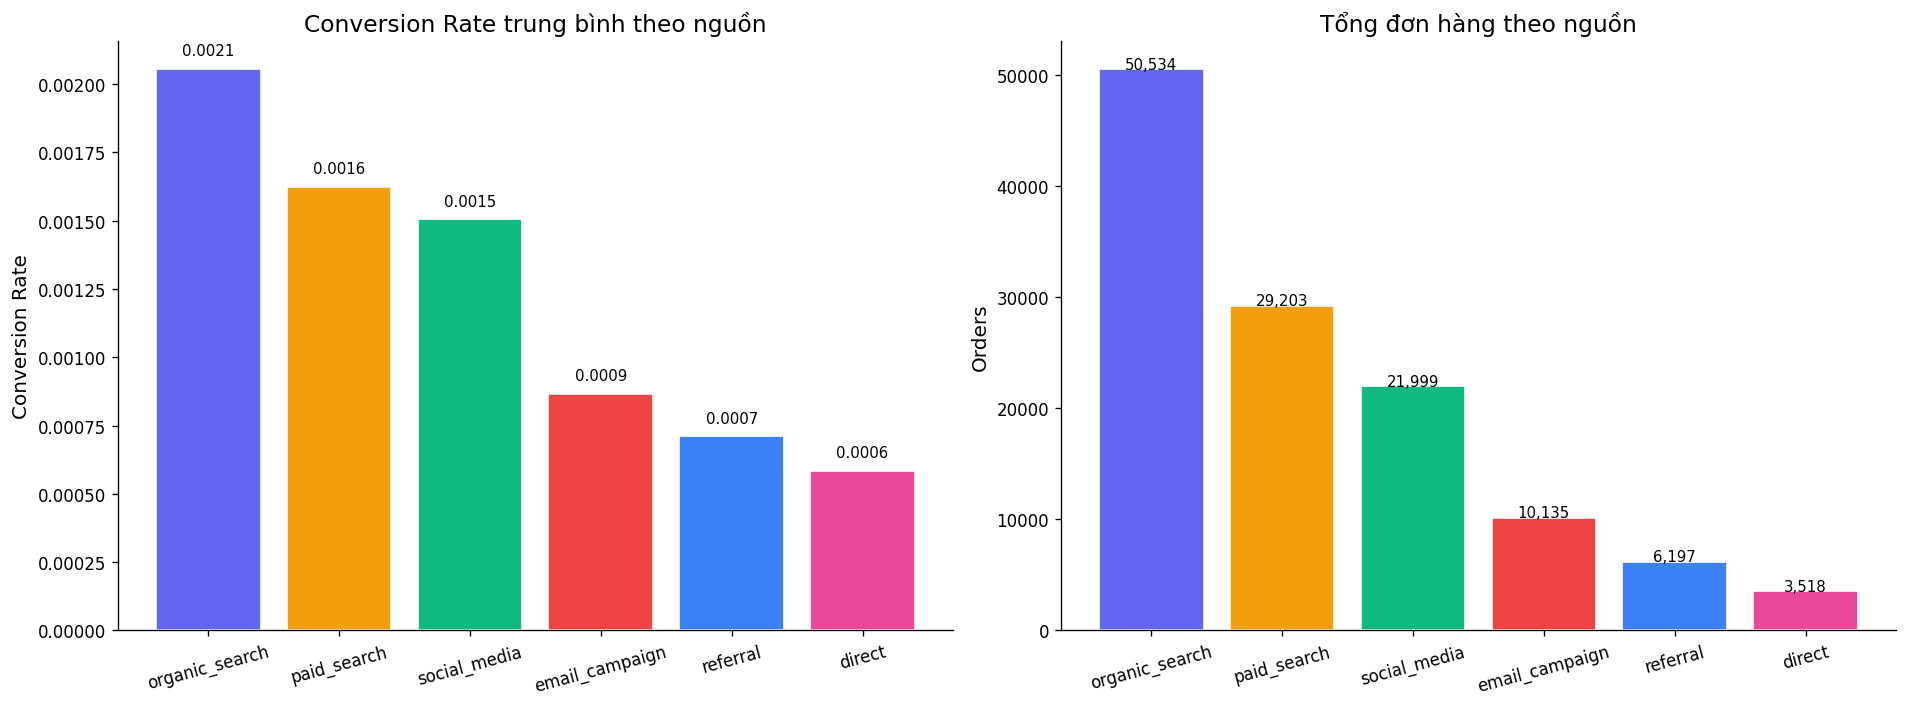

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cr = df.groupby('traffic_source')['conversion_rate'].mean().sort_values(ascending=False)
bars = axes[0].bar(cr.index, cr.values, color=PALETTE[:len(cr)], edgecolor='white')
axes[0].set_title('Conversion Rate trung bình theo nguồn')
axes[0].set_ylabel('Conversion Rate')
for bar, v in zip(bars, cr.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.00005, f'{v:.4f}', ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

orders = df.groupby('traffic_source')['orders_n'].sum().sort_values(ascending=False)
bars2 = axes[1].bar(orders.index, orders.values, color=PALETTE[:len(orders)], edgecolor='white')
axes[1].set_title('Tổng đơn hàng theo nguồn')
axes[1].set_ylabel('Orders')
for bar, v in zip(bars2, orders.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+50, f'{v:,.0f}', ha='center', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

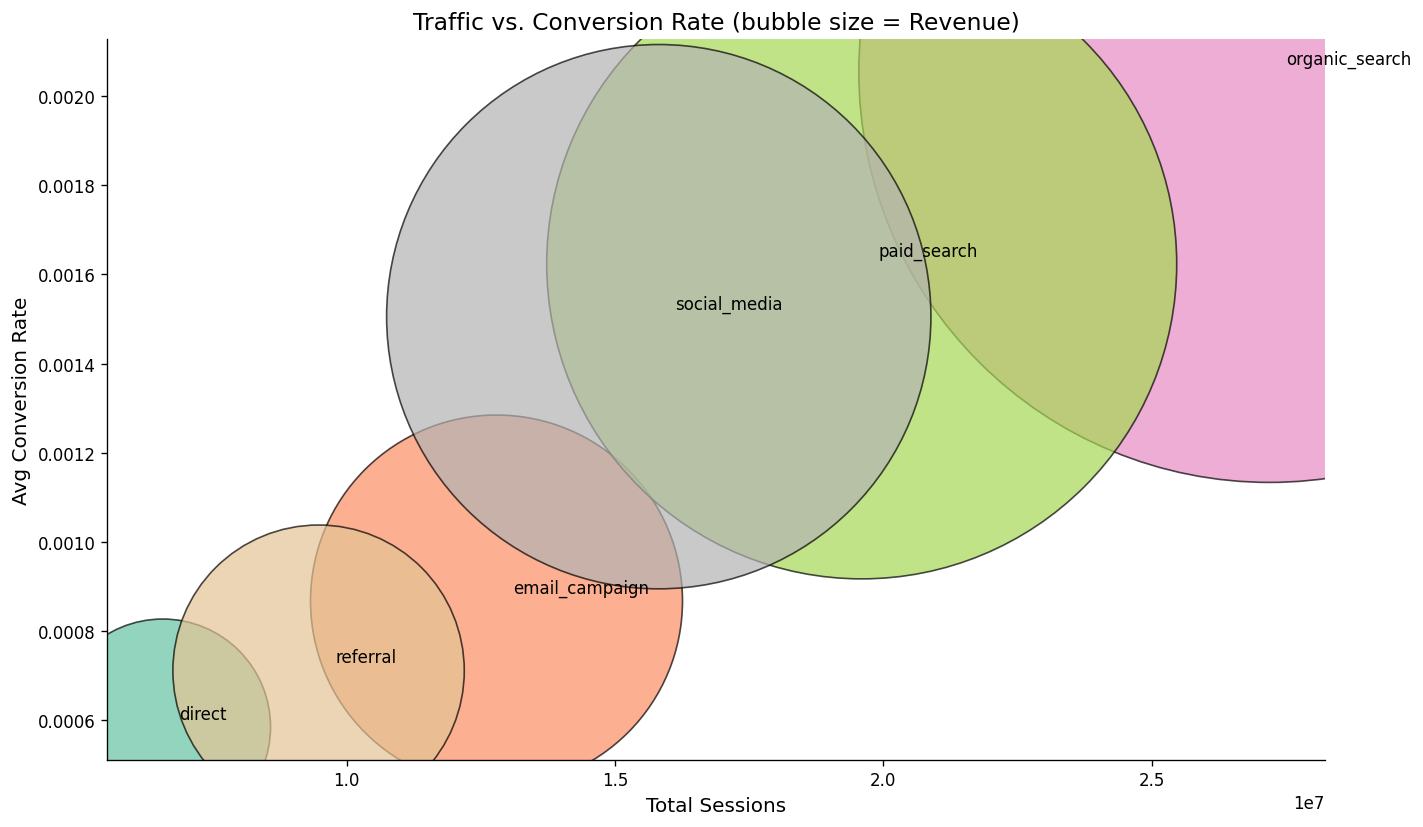

In [17]:
src_agg = df.groupby('traffic_source').agg(
    sessions=('sessions','sum'),
    conversion_rate=('conversion_rate','mean'),
    revenue=('revenue_net','sum'),
    orders=('orders_n','sum'),
    aov=('AOV','mean')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(src_agg['sessions'], src_agg['conversion_rate'],
                     s=src_agg['revenue']/5000, alpha=0.7,
                     c=range(len(src_agg)), cmap='Set2', edgecolors='black', linewidths=1)
for _, row in src_agg.iterrows():
    ax.annotate(row['traffic_source'],
                (row['sessions'], row['conversion_rate']),
                textcoords='offset points', xytext=(10, 5), fontsize=10)
ax.set_xlabel('Total Sessions')
ax.set_ylabel('Avg Conversion Rate')
ax.set_title('Traffic vs. Conversion Rate (bubble size = Revenue)')
plt.tight_layout()
plt.show()

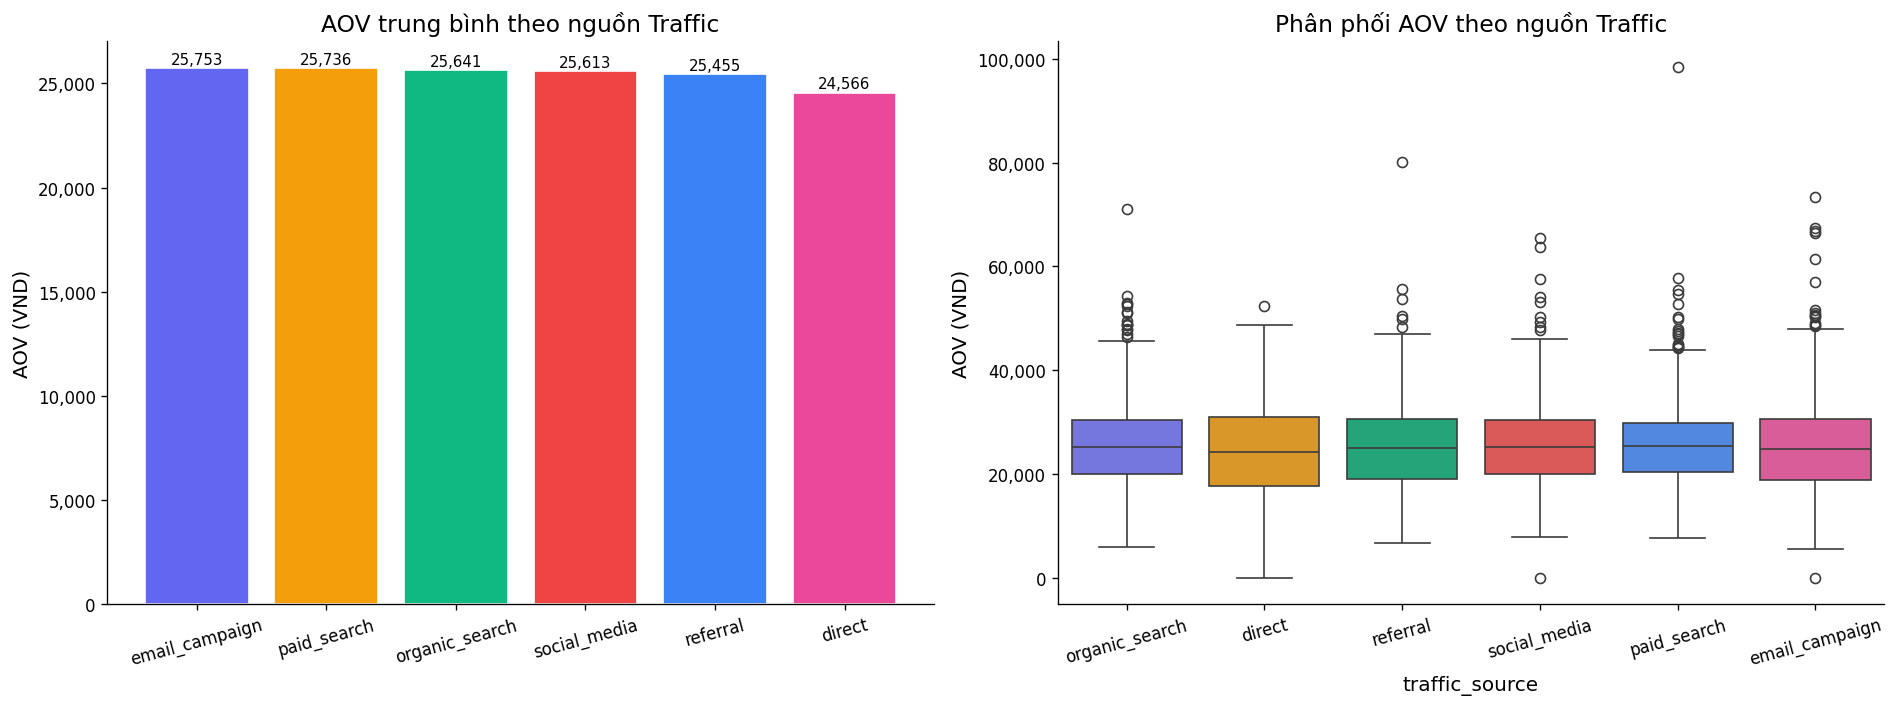

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

aov_src = df.groupby('traffic_source')['AOV'].mean().sort_values(ascending=False)
bars = axes[0].bar(aov_src.index, aov_src.values, color=PALETTE[:len(aov_src)], edgecolor='white')
axes[0].set_title('AOV trung bình theo nguồn Traffic')
axes[0].set_ylabel('AOV (VND)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, v in zip(bars, aov_src.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+200, f'{v:,.0f}', ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

# Box plot
sns.boxplot(data=df, x='traffic_source', y='AOV', palette=PALETTE, ax=axes[1])
axes[1].set_title('Phân phối AOV theo nguồn Traffic')
axes[1].set_ylabel('AOV (VND)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# 3. Phân tích Hiệu quả Kinh tế (Economic Impact)
> Nguồn traffic nào đang "nuôi sống" doanh nghiệp?

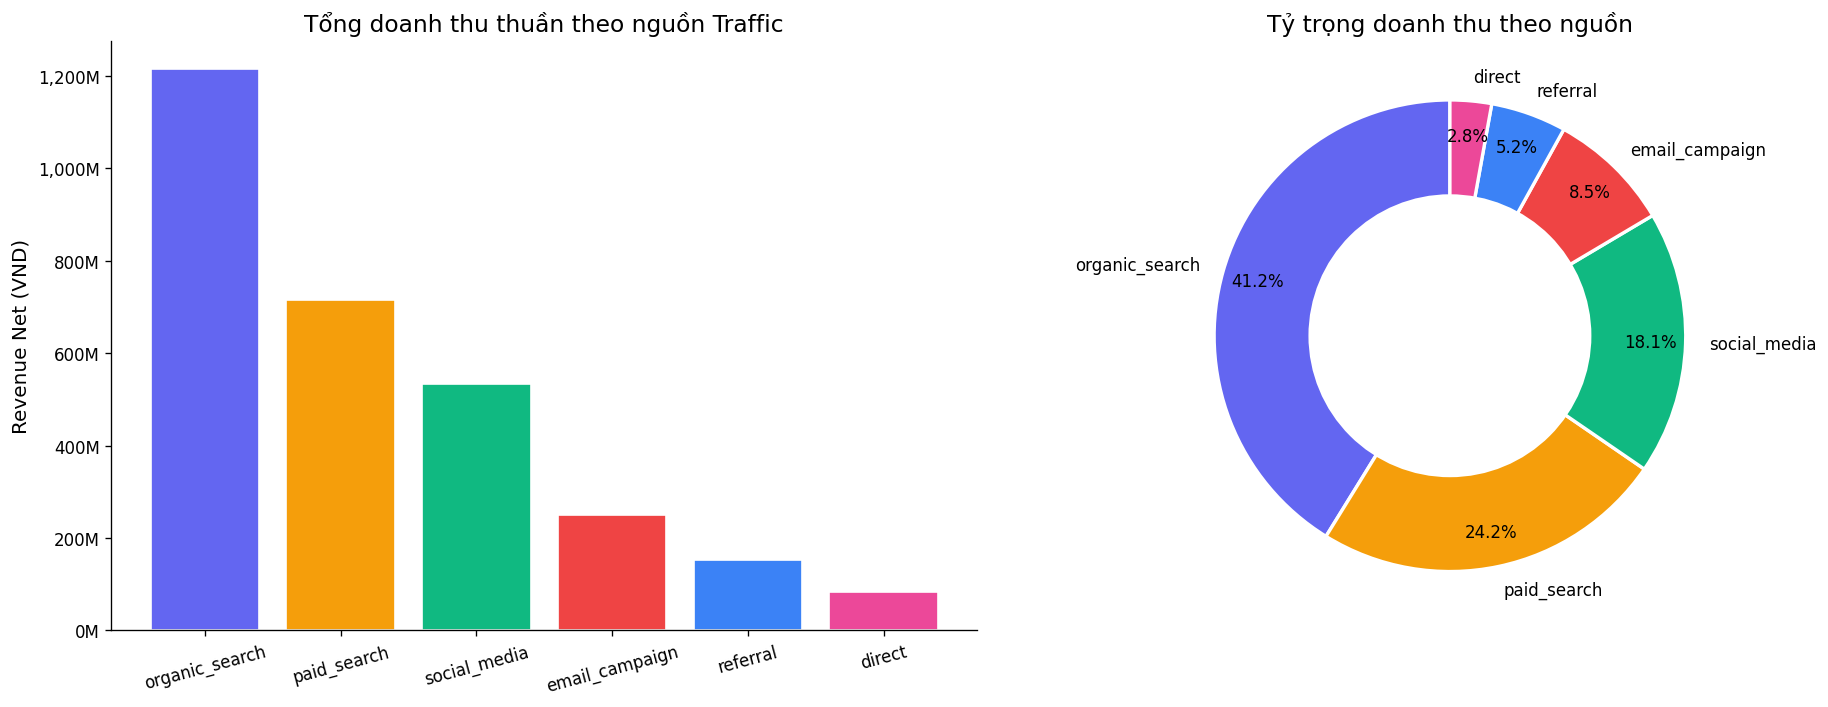

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rev_src = df.groupby('traffic_source')['revenue_net'].sum().sort_values(ascending=False)

# Bar
bars = axes[0].bar(rev_src.index, rev_src.values, color=PALETTE[:len(rev_src)], edgecolor='white')
axes[0].set_title('Tổng doanh thu thuần theo nguồn Traffic')
axes[0].set_ylabel('Revenue Net (VND)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:,.0f}M'))
axes[0].tick_params(axis='x', rotation=15)

# Pie
axes[1].pie(rev_src.values, labels=rev_src.index, autopct='%1.1f%%',
            colors=PALETTE[:len(rev_src)], startangle=90, pctdistance=0.85,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
centre = plt.Circle((0, 0), 0.60, fc='white')
axes[1].add_artist(centre)
axes[1].set_title('Tỷ trọng doanh thu theo nguồn')

plt.tight_layout()
plt.show()

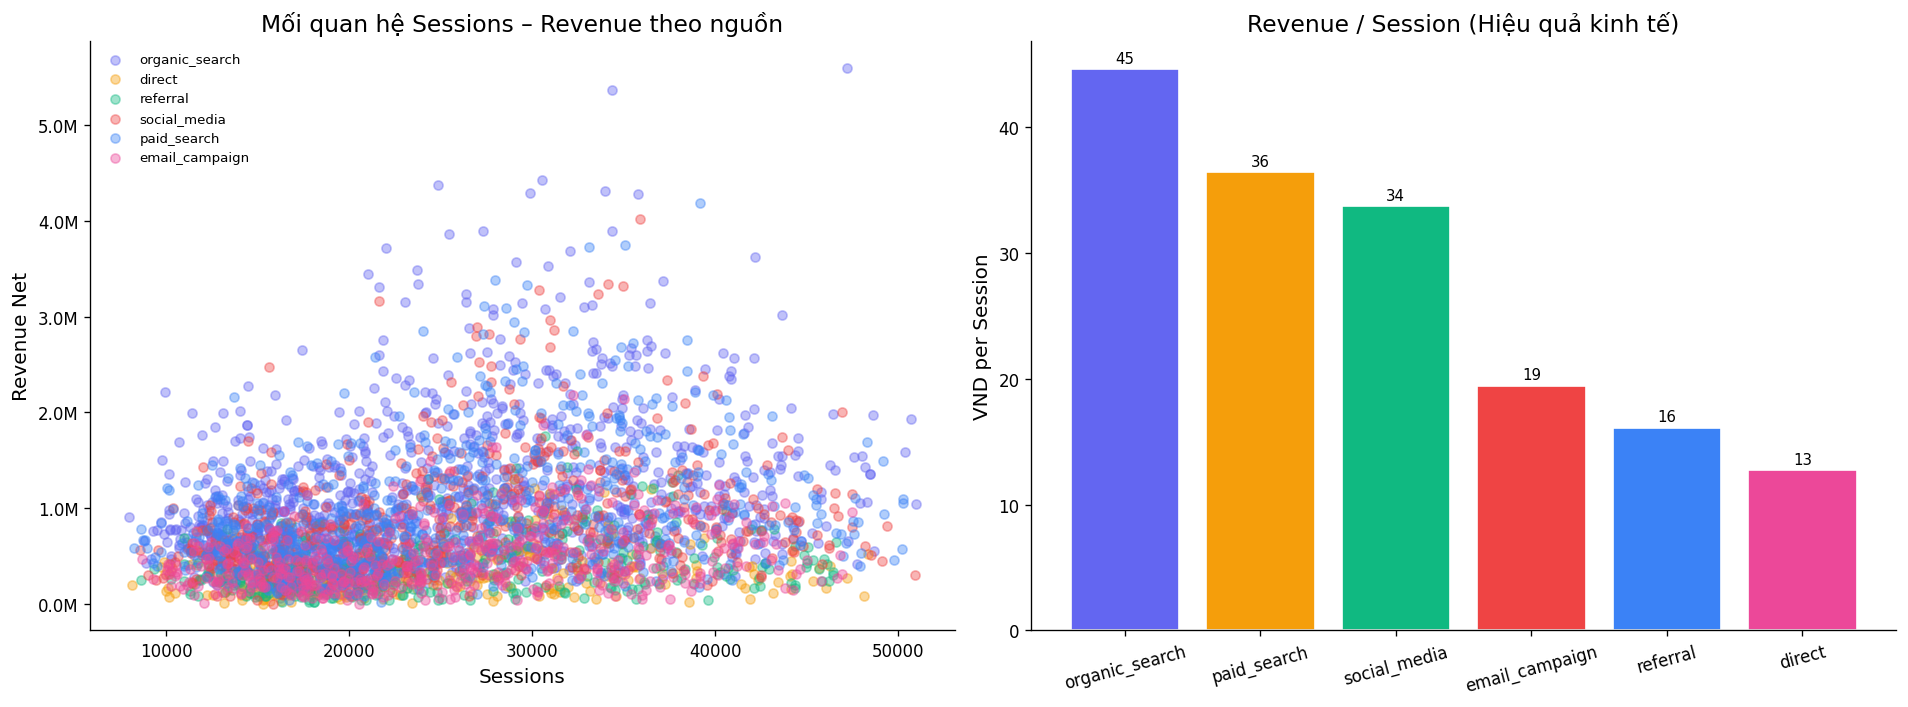

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: sessions vs revenue
for i, src in enumerate(df['traffic_source'].unique()):
    sub = df[df['traffic_source'] == src]
    axes[0].scatter(sub['sessions'], sub['revenue_net'], alpha=0.4,
                    label=src, s=30, color=PALETTE[i % len(PALETTE)])
axes[0].set_xlabel('Sessions')
axes[0].set_ylabel('Revenue Net')
axes[0].set_title('Mối quan hệ Sessions – Revenue theo nguồn')
axes[0].legend(frameon=False, fontsize=8)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Revenue per session (efficiency)
eff = (df.groupby('traffic_source')['revenue_net'].sum() /
       df.groupby('traffic_source')['sessions'].sum()).sort_values(ascending=False)
bars = axes[1].bar(eff.index, eff.values, color=PALETTE[:len(eff)], edgecolor='white')
axes[1].set_title('Revenue / Session (Hiệu quả kinh tế)')
axes[1].set_ylabel('VND per Session')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, v in zip(bars, eff.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:,.0f}', ha='center', fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# 4. Actionable Insights – Bảng tổng hợp & Phân loại nguồn Traffic
> Phân loại nguồn traffic theo ma trận chiến lược

In [21]:
pivot = df.groupby('traffic_source').agg(
    total_sessions=('sessions', 'sum'),
    total_visitors=('unique_visitors', 'sum'),
    total_orders=('orders_n', 'sum'),
    total_revenue=('revenue_net', 'sum'),
    avg_bounce_rate=('bounce_rate', 'mean'),
    avg_duration=('avg_session_duration_sec', 'mean'),
    avg_cr=('conversion_rate', 'mean'),
    avg_aov=('AOV', 'mean'),
    avg_return_ratio=('return_ratio', 'mean'),
    avg_page_views=('page_views', 'mean'),
).round(4)

pivot['revenue_per_session'] = (pivot['total_revenue'] / pivot['total_sessions']).round(2)
pivot = pivot.sort_values('total_revenue', ascending=False)
pivot.style.format({
    'total_sessions': '{:,.0f}',
    'total_visitors': '{:,.0f}',
    'total_orders': '{:,.0f}',
    'total_revenue': '{:,.0f}',
    'avg_aov': '{:,.0f}',
    'revenue_per_session': '{:,.0f}',
    'avg_bounce_rate': '{:.4f}',
    'avg_cr': '{:.4f}',
    'avg_return_ratio': '{:.3f}',
    'avg_duration': '{:.0f}',
    'avg_page_views': '{:,.0f}',
}).background_gradient(cmap='YlOrRd', axis=0)

,total_sessions,total_visitors,total_orders,total_revenue,avg_bounce_rate,avg_duration,avg_cr,avg_aov,avg_return_ratio,avg_page_views,revenue_per_session
traffic_source,,,,,,,,,,,
organic_search,"27,196,976","20,625,107","50,534","1,214,210,252",0.0045,211,0.0021,"25,641",1.322,"107,896",45
paid_search,"19,598,271","14,922,386","29,203","714,433,395",0.0045,209,0.0016,"25,736",1.317,"108,520",36
social_media,"15,816,226","12,048,065","21,999","533,283,953",0.0045,210,0.0015,"25,613",1.316,"107,709",34
email_campaign,"12,792,670","9,700,462","10,135","249,086,236",0.0045,213,0.0009,"25,753",1.321,"109,857",19
referral,"9,476,845","7,220,019","6,197","152,817,317",0.0045,208,0.0007,"25,455",1.316,"111,082",16
direct,"6,571,549","4,986,650","3,518","83,805,750",0.0045,208,0.0006,"24,566",1.319,"108,163",13


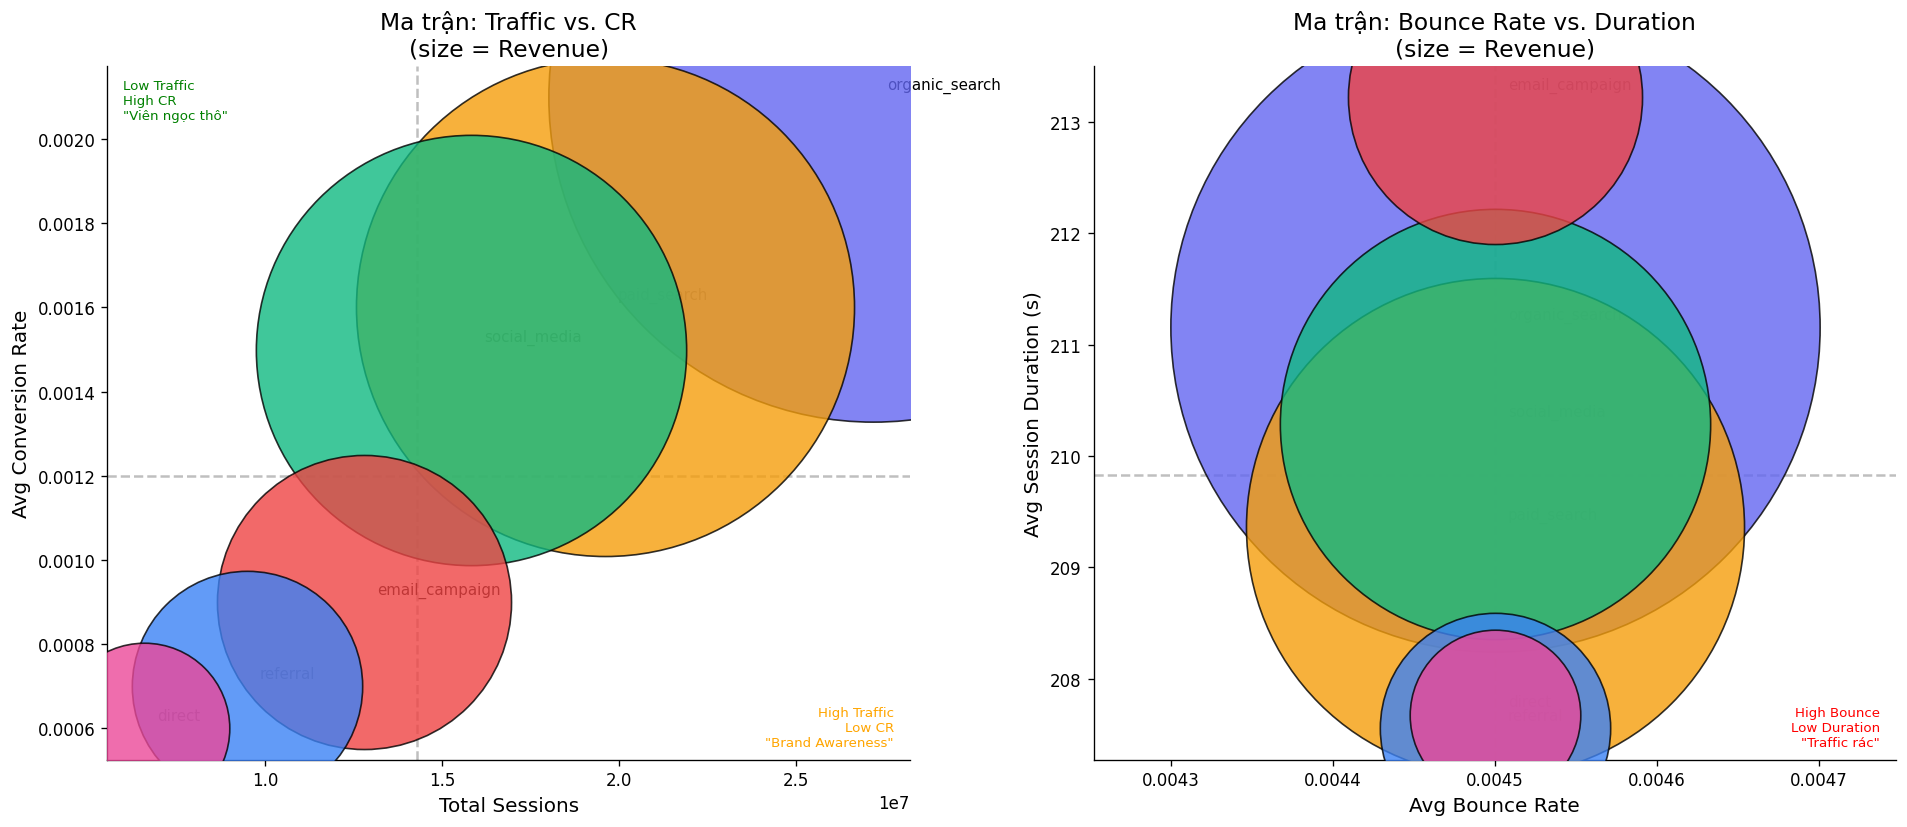

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Quadrant 1: Traffic vs CR
med_sess = pivot['total_sessions'].median()
med_cr   = pivot['avg_cr'].median()
for i, (src, row) in enumerate(pivot.iterrows()):
    axes[0].scatter(row['total_sessions'], row['avg_cr'],
                    s=row['total_revenue']/8000, color=PALETTE[i % len(PALETTE)],
                    edgecolors='black', linewidths=1, alpha=0.8, zorder=5)
    axes[0].annotate(src, (row['total_sessions'], row['avg_cr']),
                     textcoords='offset points', xytext=(8, 5), fontsize=9)
axes[0].axhline(med_cr, color='gray', ls='--', alpha=0.5)
axes[0].axvline(med_sess, color='gray', ls='--', alpha=0.5)
axes[0].set_xlabel('Total Sessions')
axes[0].set_ylabel('Avg Conversion Rate')
axes[0].set_title('Ma trận: Traffic vs. CR\n(size = Revenue)')
axes[0].text(0.02, 0.98, 'Low Traffic\nHigh CR\n"Viên ngọc thô"', transform=axes[0].transAxes, va='top', fontsize=8, color='green')
axes[0].text(0.98, 0.02, 'High Traffic\nLow CR\n"Brand Awareness"', transform=axes[0].transAxes, ha='right', fontsize=8, color='orange')

# Quadrant 2: Bounce vs Duration
med_bounce = pivot['avg_bounce_rate'].median()
med_dur    = pivot['avg_duration'].median()
for i, (src, row) in enumerate(pivot.iterrows()):
    axes[1].scatter(row['avg_bounce_rate'], row['avg_duration'],
                    s=row['total_revenue']/8000, color=PALETTE[i % len(PALETTE)],
                    edgecolors='black', linewidths=1, alpha=0.8, zorder=5)
    axes[1].annotate(src, (row['avg_bounce_rate'], row['avg_duration']),
                     textcoords='offset points', xytext=(8, 5), fontsize=9)
axes[1].axhline(med_dur, color='gray', ls='--', alpha=0.5)
axes[1].axvline(med_bounce, color='gray', ls='--', alpha=0.5)
axes[1].set_xlabel('Avg Bounce Rate')
axes[1].set_ylabel('Avg Session Duration (s)')
axes[1].set_title('Ma trận: Bounce Rate vs. Duration\n(size = Revenue)')
axes[1].text(0.98, 0.02, 'High Bounce\nLow Duration\n"Traffic rác"', transform=axes[1].transAxes, ha='right', fontsize=8, color='red')

plt.tight_layout()
plt.show()

# 5. Phân tích theo thời gian (Time-series Analysis)
> Phát hiện tính chu kỳ, xu hướng và hiệu quả chiến dịch

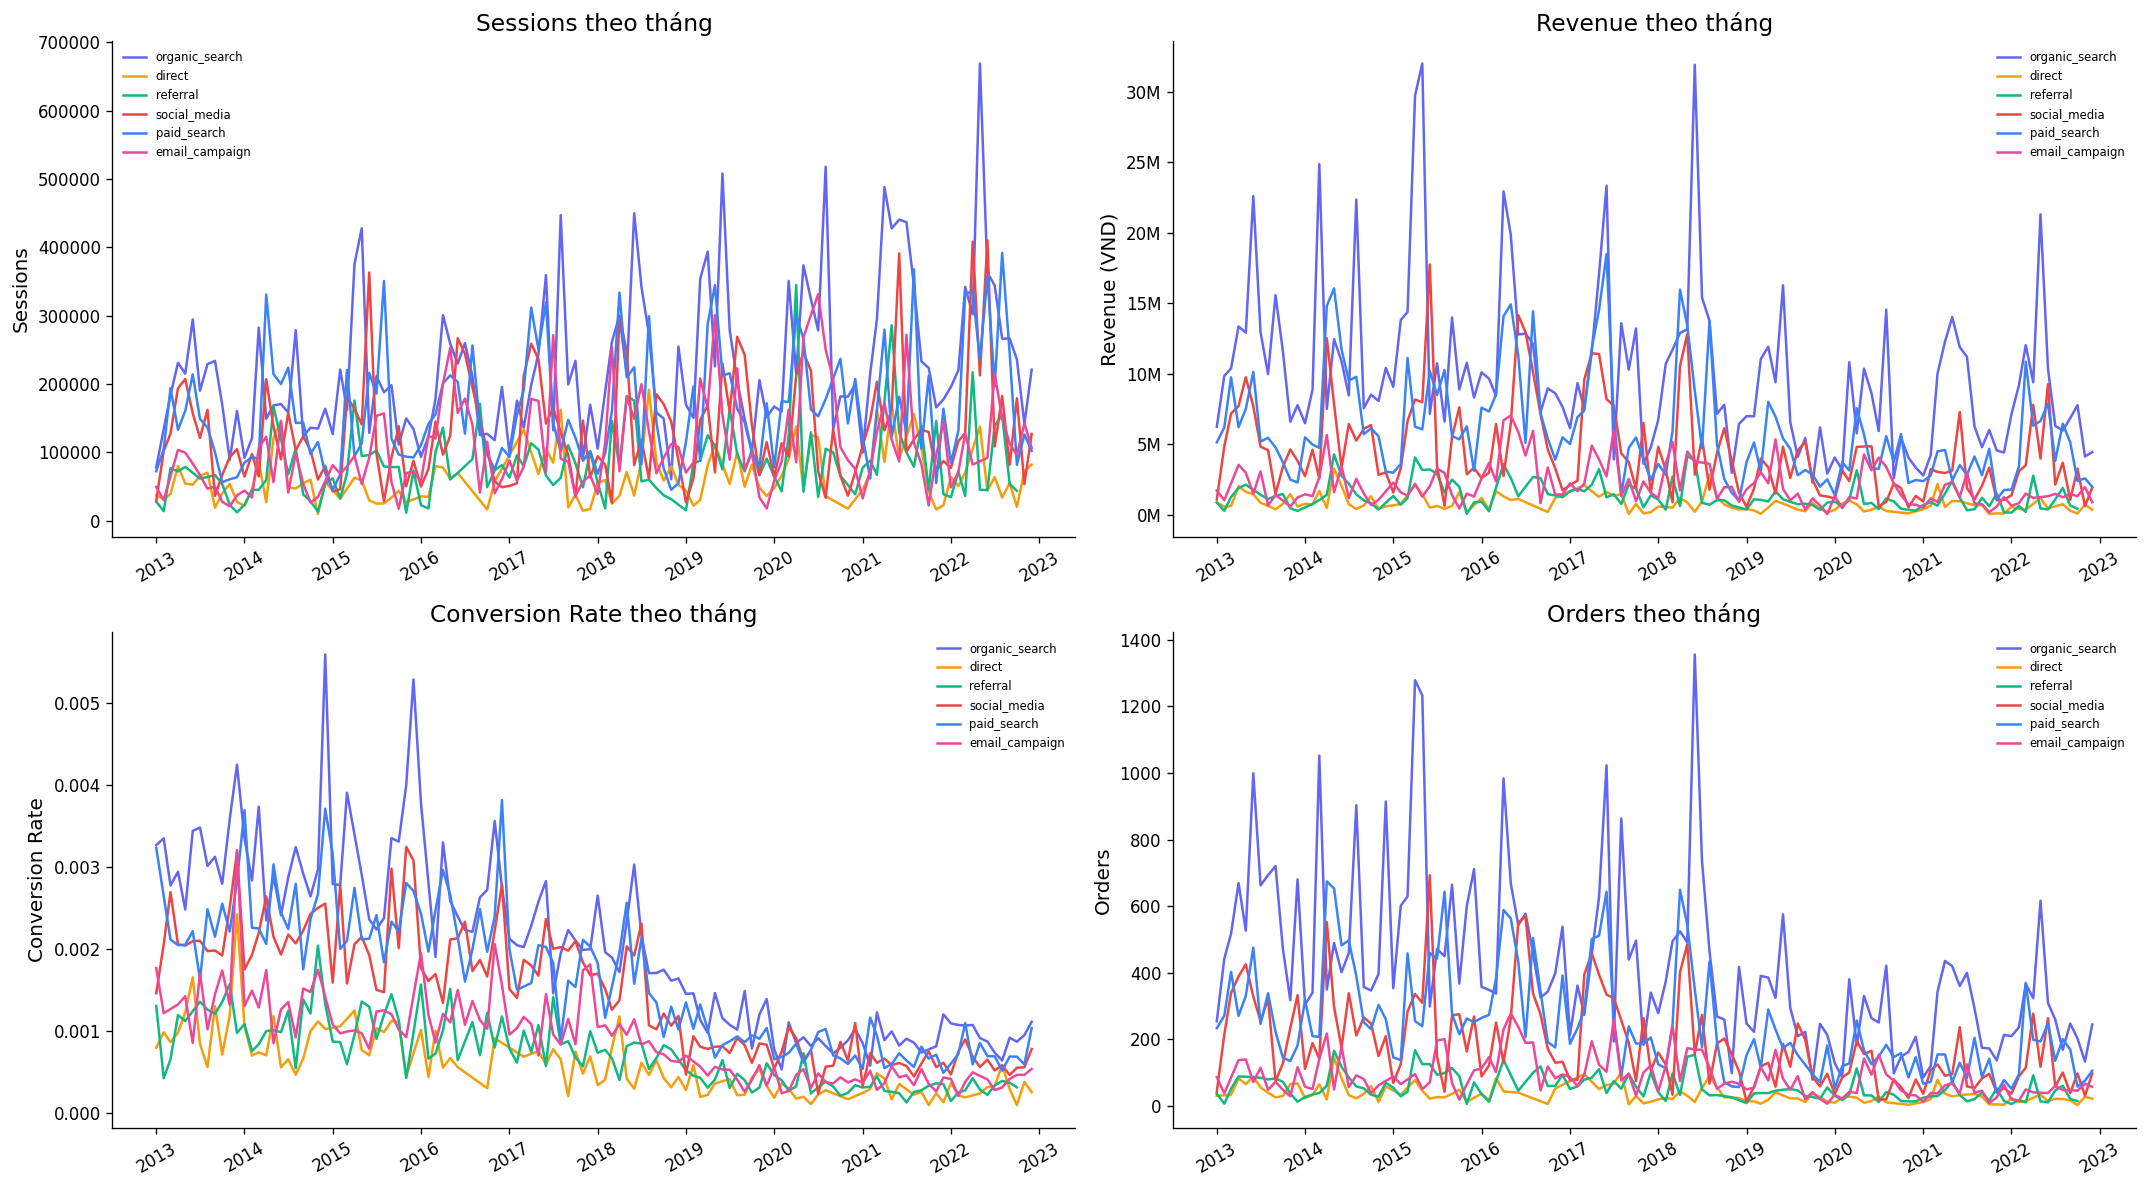

In [23]:
monthly = df.groupby([df['date'].dt.to_period('M'), 'traffic_source']).agg(
    sessions=('sessions','sum'),
    revenue=('revenue_net','sum'),
    cr=('conversion_rate','mean'),
    orders=('orders_n','sum')
).reset_index()
monthly['date'] = monthly['date'].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for src in df['traffic_source'].unique():
    sub = monthly[monthly['traffic_source'] == src]
    axes[0,0].plot(sub['date'], sub['sessions'], label=src, linewidth=1.5)
    axes[0,1].plot(sub['date'], sub['revenue'], label=src, linewidth=1.5)
    axes[1,0].plot(sub['date'], sub['cr'], label=src, linewidth=1.5)
    axes[1,1].plot(sub['date'], sub['orders'], label=src, linewidth=1.5)

for ax, title, ylabel in zip(axes.flat,
    ['Sessions theo tháng', 'Revenue theo tháng', 'Conversion Rate theo tháng', 'Orders theo tháng'],
    ['Sessions', 'Revenue (VND)', 'Conversion Rate', 'Orders']):
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, frameon=False)
    ax.tick_params(axis='x', rotation=30)

axes[0,1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

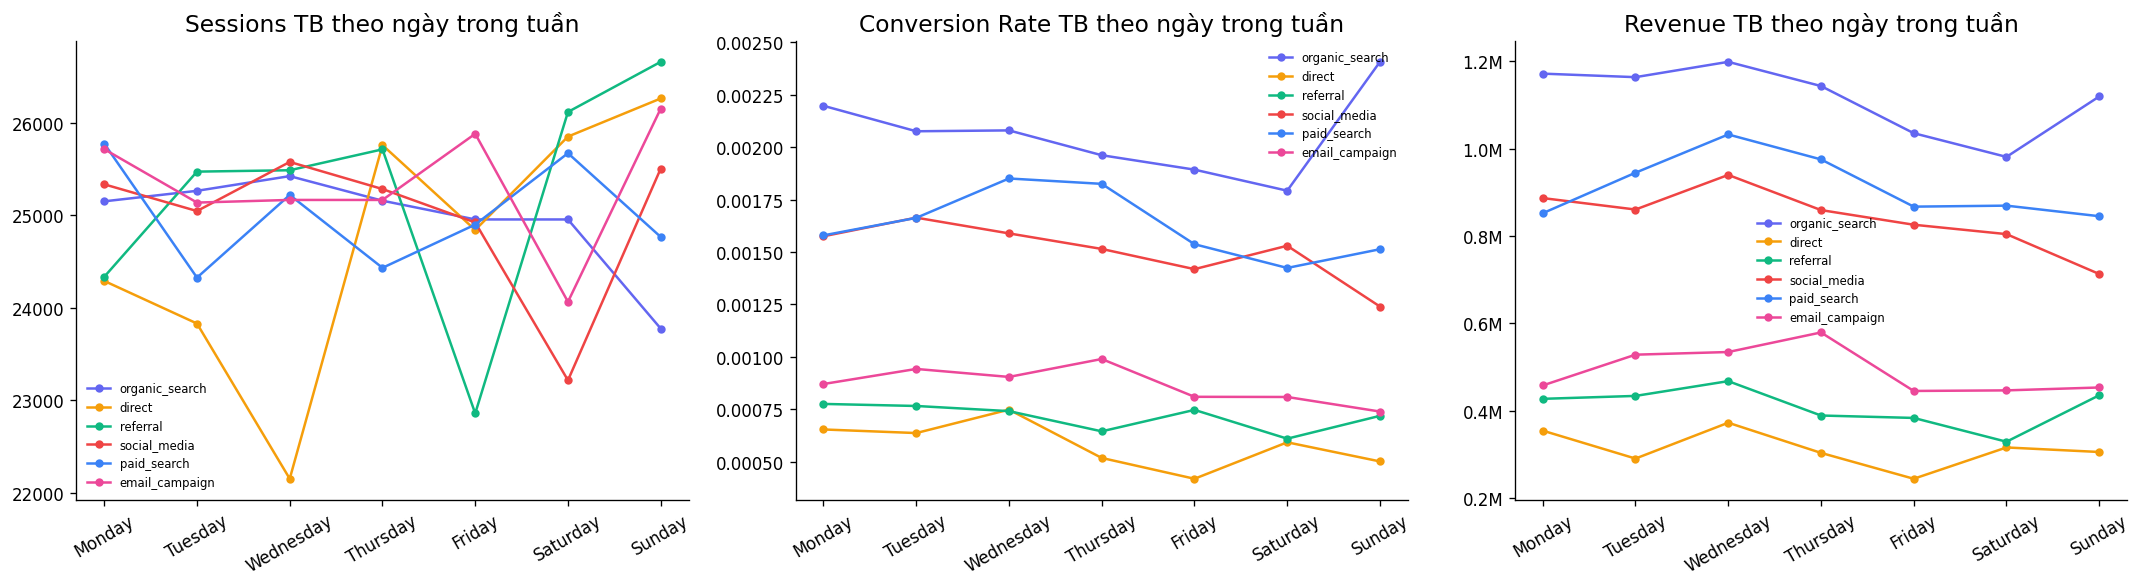

In [24]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for src in df['traffic_source'].unique():
    sub = df[df['traffic_source'] == src]
    dow = sub.groupby('day_name')['sessions'].mean().reindex(dow_order)
    axes[0].plot(dow.index, dow.values, marker='o', markersize=4, label=src, linewidth=1.5)

    dow_cr = sub.groupby('day_name')['conversion_rate'].mean().reindex(dow_order)
    axes[1].plot(dow_cr.index, dow_cr.values, marker='o', markersize=4, label=src, linewidth=1.5)

    dow_rev = sub.groupby('day_name')['revenue_net'].mean().reindex(dow_order)
    axes[2].plot(dow_rev.index, dow_rev.values, marker='o', markersize=4, label=src, linewidth=1.5)

axes[0].set_title('Sessions TB theo ngày trong tuần')
axes[1].set_title('Conversion Rate TB theo ngày trong tuần')
axes[2].set_title('Revenue TB theo ngày trong tuần')
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=7, frameon=False)

plt.tight_layout()
plt.show()

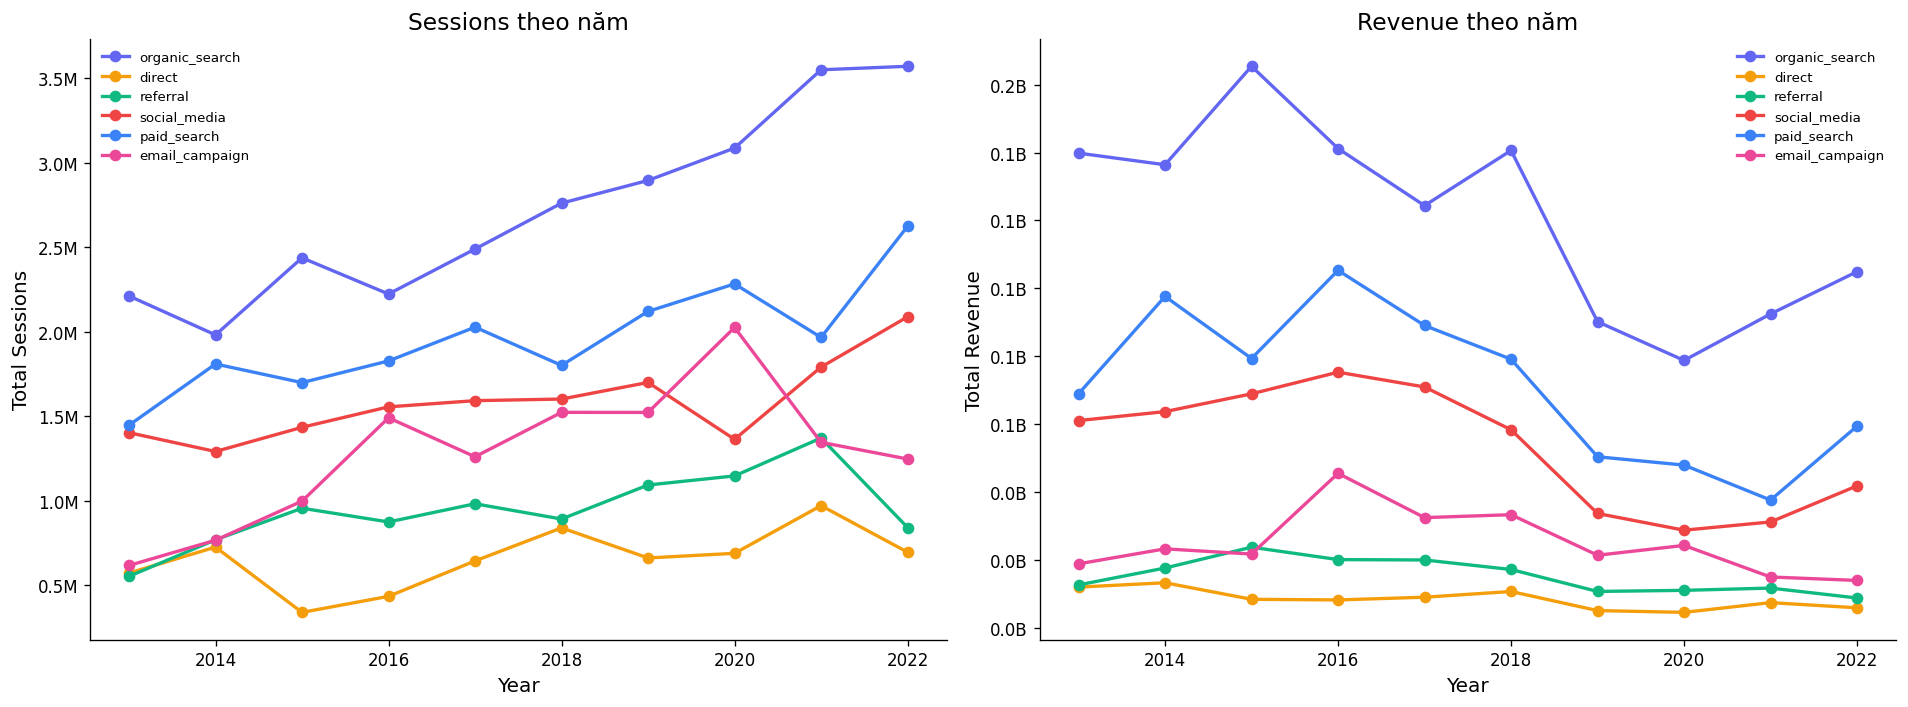

In [25]:
yearly = df.groupby(['year','traffic_source']).agg(
    sessions=('sessions','sum'),
    revenue=('revenue_net','sum'),
    orders=('orders_n','sum'),
    cr=('conversion_rate','mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for src in df['traffic_source'].unique():
    sub = yearly[yearly['traffic_source'] == src]
    axes[0].plot(sub['year'], sub['sessions'], marker='o', label=src, linewidth=2)
    axes[1].plot(sub['year'], sub['revenue'], marker='o', label=src, linewidth=2)

axes[0].set_title('Sessions theo năm')
axes[0].set_ylabel('Total Sessions')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[1].set_title('Revenue theo năm')
axes[1].set_ylabel('Total Revenue')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

for ax in axes:
    ax.legend(fontsize=8, frameon=False)
    ax.set_xlabel('Year')

plt.tight_layout()
plt.show()

# 6. (Mở rộng) Correlation Matrix & Tổng kết
> Ma trận tương quan giữa các chỉ số chính

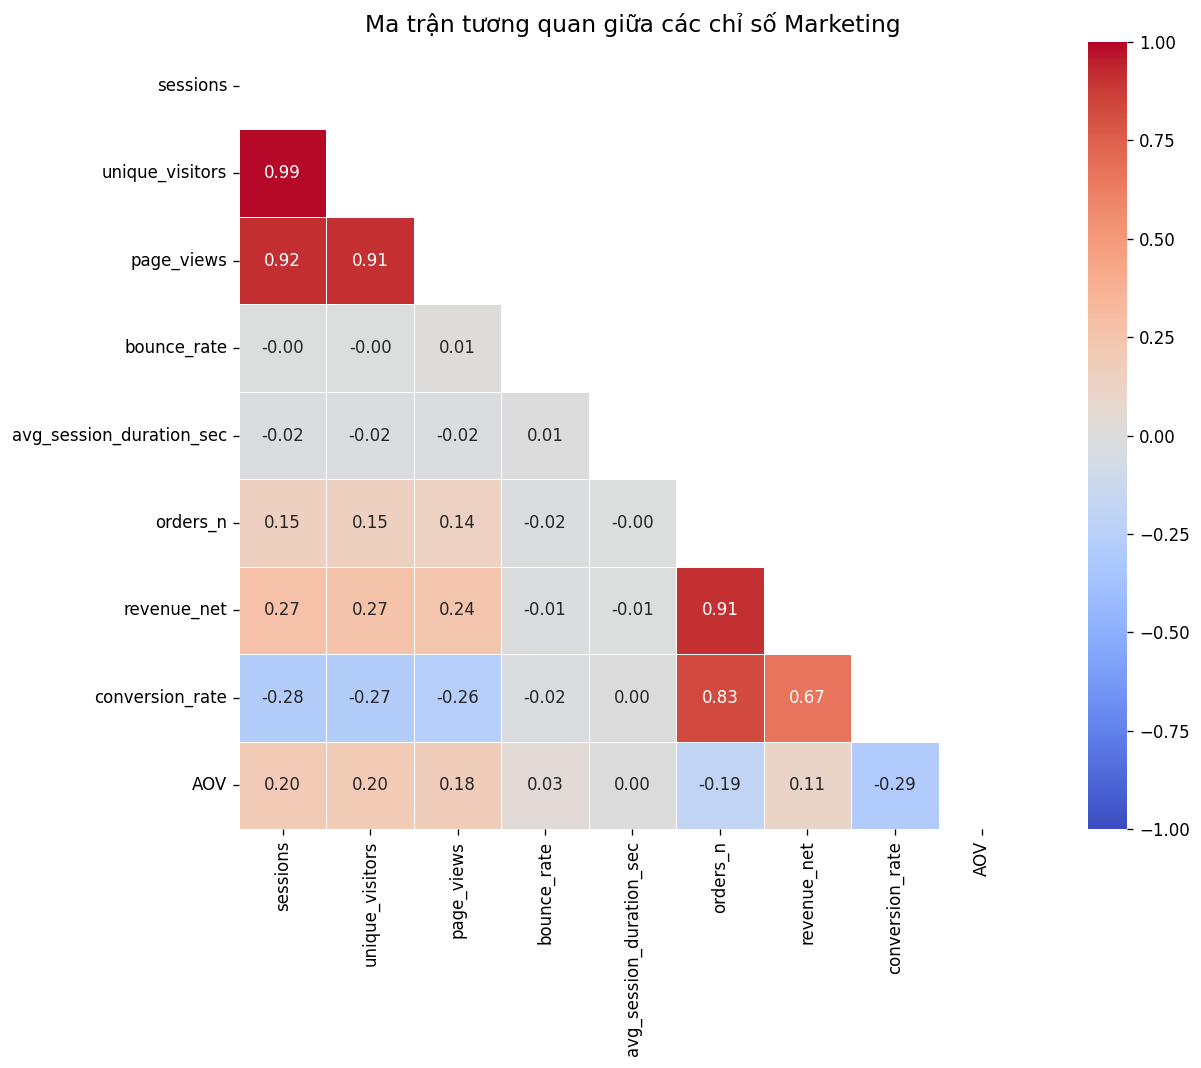

In [26]:
numeric_cols = ['sessions','unique_visitors','page_views','bounce_rate',
                'avg_session_duration_sec','orders_n','revenue_net','conversion_rate','AOV']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            square=True)
ax.set_title('Ma trận tương quan giữa các chỉ số Marketing')
plt.tight_layout()
plt.show()

In [27]:

summary = pivot[['total_sessions','avg_cr','avg_bounce_rate','avg_duration','avg_aov','total_revenue']].copy()
def classify(row):
    labels = []
    med_s = summary['total_sessions'].median()
    med_c = summary['avg_cr'].median()
    if row['total_sessions'] > med_s and row['avg_cr'] < med_c:
        labels.append('High Traffic - Low CR (Brand Awareness)')
    if row['total_sessions'] < med_s and row['avg_cr'] > med_c:
        labels.append('Low Traffic - High CR (Viên ngọc thô)')
    if row['avg_bounce_rate'] > summary['avg_bounce_rate'].median() and row['avg_duration'] < summary['avg_duration'].median():
        labels.append('High Bounce - Low Duration (Traffic rác)')
    if row['avg_aov'] > summary['avg_aov'].median():
        labels.append('High AOV (Khách VIP)')
    return ' | '.join(labels) if labels else 'Balanced'

summary['classification'] = summary.apply(classify, axis=1)
summary.style.format({
    'total_sessions': '{:,.0f}',
    'total_revenue': '{:,.0f}',
    'avg_aov': '{:,.0f}',
    'avg_cr': '{:.4f}',
    'avg_bounce_rate': '{:.4f}',
    'avg_duration': '{:.0f}',
}).background_gradient(subset=['total_revenue','avg_cr'], cmap='Greens', axis=0)

,total_sessions,avg_cr,avg_bounce_rate,avg_duration,avg_aov,total_revenue,classification
traffic_source,,,,,,,
organic_search,"27,196,976",0.0021,0.0045,211,"25,641","1,214,210,252",High AOV (Khách VIP)
paid_search,"19,598,271",0.0016,0.0045,209,"25,736","714,433,395",High AOV (Khách VIP)
social_media,"15,816,226",0.0015,0.0045,210,"25,613","533,283,953",Balanced
email_campaign,"12,792,670",0.0009,0.0045,213,"25,753","249,086,236",High AOV (Khách VIP)
referral,"9,476,845",0.0007,0.0045,208,"25,455","152,817,317",Balanced
direct,"6,571,549",0.0006,0.0045,208,"24,566","83,805,750",Balanced
